# Midterm Exam (part 2) - Computational Physics I

### Date: Thursday 3 April 2025
### Credits: 10 points

### Duration: 1 hour

## Name: 

### Instructions:

- When you finish, please send me the **.ipynb** file via email to wbanda@yachaytech.edu.ec


- The exam is individual. Please include your name in the notebook.


- Within a **single python notebook**, solve the following problems:

## 5. I/O and regression: Larmor precession (5 points) 

This problem consists of analysing the relationship between magnetic field strength and Larmor precession frequency, a fundamental principle in Nuclear Magnetic Resonance (NMR). To this end, a simulated dataset was generated, mimicking experimental measurements, and stored in a CSV file. This dataset contains pairs of values: **magnetic field strength (in Tesla)** and the corresponding observed **Larmor frequency (in Hertz)**. The goal is to investigate the relationship predicted by the **Larmor equation**.

#### Data:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/1D-data/larmor_precession_data.csv

a) Create a pandas-based python I/O function that opens the above data file and returns $2$ arrays, one for the magnetic field strength and one for the Larmor frequency.

b) Call your I/O function and make a high-quality labeled plot of Larmor frequency (in the Y axis) versus magnetic field strength (in the X axis).

c) Write down and use a physical model (motivated by quantum mechanics) to carry out a regression and constrain any free parameters in the model.

d) Report the results from your regression, i.e. the best-fit value for the free parameter/s with respective uncertainty/ies.

e) Make a plot showing the empirical data and the best-fit model obtained from your regression.  Based on your analysis, can you infer the particle assumed for the simulated data?


##### Reference for Larmor precession: https://github.com/wbandabarragan/quantum-mechanics-1/blob/main/unit-4/Lecture-Notes-UC4.pdf

## 6. Image processing: Scanning Electron Microscope of Escherichia coli (5 points)

This problem consists of analysing the reduction of the **bacteria Escherichia coli (E. coli)** after treatment with **Zinc oxide (ZnO) nanoparticles**. The images provided below were obtained from a **Scanning Electron Microscope (SEM)**, before and after 5 hours of treatment with ZnO. One pixel of  the image has an area of $0.02^2\mu m^2$.

#### SEM image before ZnO treatment:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/bacteria_before.jpg

#### SEM image after ZnO treatment:
https://github.com/wbandabarragan/physics-teaching-data/blob/main/2D-data/bacteria_after.jpg

To analyse how effective this antibacterial treatment is, carry out the following analysis in python:

a) Create a python function that reads in an image file and returns one its channels as an array.

b) Call your function from (a), and:

- Make a 2-panel figure showing the before and after SEM images.
- Make a 2-panel figure showing the before and after pixel histograms of the SEM images.

c) Create a python function that isolates the area covered by the E. coli bacteria from the background. Your function should read in an image channel array and return a cleaned binary image array with zeroes in the background and ones in the E. coli area.

d) Call your function from (c), and:

- Make a 2-panel figure showing the before and after binary images.
- Make a 2-panel figure showing the before and after pixel histograms of the binary images.

e) Using your binary images, calculate the following:

- The total area in pixels and physical units covered by the E. coli bateria before and after treatment.
- The ratio between such areas, how effective is the antibacterial treatment with ZnO nanoparticles?

##### SEM images reference: Zhang et al. 2007, https://link.springer.com/article/10.1007/s11051-006-9150-1

# 5. I/O and regression: Larmor precession (5 points) 
### a) Create a pandas-based python I/O function that opens the above data file and returns $2$ arrays, one for the magnetic field strength and one for the Larmor frequency.

In [1]:
#Import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as opt

In [2]:
def io_csv(filename):
    '''
    This function reads a csv file and returns two arrays.
    Input: "filename" (str, this should be the path to the file)
    Output: numpy arrays
    '''
   #Read the file
    file1 = pd.read_csv(filename) #the file is comma separated, so it's no necessary to declare a separation

    #Get the columns out as arrays
    b_stg = np.array(file1["B (Tesla)"])
    freq = np.array(file1["Frequency (Hz)"])

    return b_stg, freq

### b) Call your I/O function and make a high-quality labeled plot of Larmor frequency (in the Y axis) versus magnetic field strength (in the X axis).

In [3]:
filename = "/home/prostofsound/jnotebooks/computational-physics-1/exams/data/larmor_precession_data.csv"

b_stg, freq = io_csv(filename)

In [4]:
print(b_stg.shape, freq.shape)
print(np.min(freq), np.max(freq))
print(np.min(b_stg), np.max(b_stg))

(100,) (100,)
26877748.98187103 268513491.831138
0.1 1.0


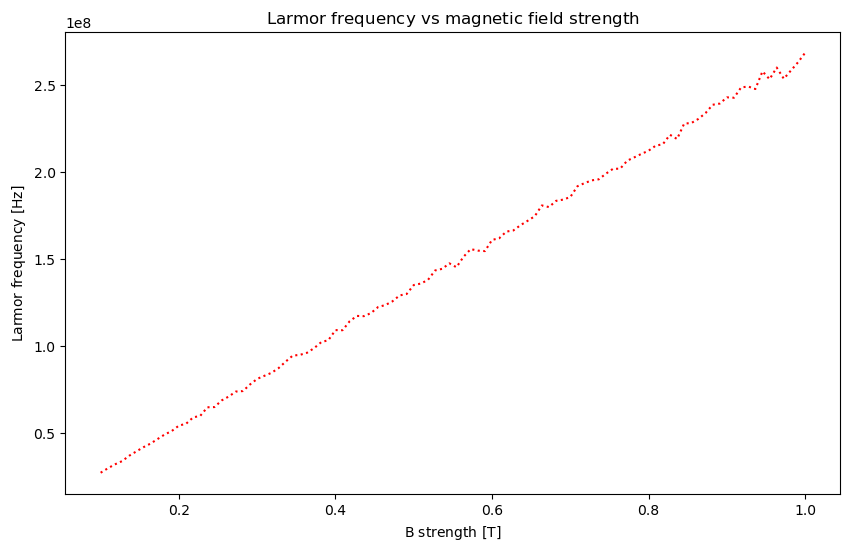

In [5]:
#Plotting
plt.figure(figsize=(10,6))

# Plot
plt.plot(b_stg, freq, color = "red", linestyle = ":")

# Title with latex syntax
plt.title(r"$\text{Larmor frequency vs magnetic field strength}$") 

# Axes titles
plt.xlabel(r"$\text{B strength [T]}$")
plt.ylabel(r"$\text{Larmor frequency [Hz]}$")

# Show/Save
plt.show()
plt.close()

### c) Write down and use a physical model (motivated by quantum mechanics) to carry out a regression and constrain any free parameters in the model.

The Larmor frequency is given by,
$$
\omega = \gamma B
$$
$B$ is the magnitude of the applied magnetic field, and $\gamma$ is the gyromagnetic ratio for a particle of charge $-e$.

In [6]:
def larmor_model(b_stg, gamma):
    """
    This model returns the Larmor frequency, given the gyromagnetic ratio gamma.
    Inputs: B_stg (array), gamma(float)
    Outputs: omega(array)
    """
    omega = gamma*b_stg

    return omega

In [7]:
#Regression
coef, cova = opt.curve_fit(larmor_model, b_stg, freq)

### d) Report the results from your regression, i.e. the best-fit value for the free parameter/s with respective uncertainty/ies.

In [8]:
uncert = np.sqrt(np.diag(cova))

In [9]:
print("The best found value for gamma (the proportionality constant) is", "{:.2e}".format(*coef),\
      "with uncertainty", "{:.2e}".format(*uncert))
print("\n")
print("gamma has units of [1/(s*T)]")

The best found value for gamma (the proportionality constant) is 2.67e+08 with uncertainty 2.78e+05


gamma has units of [1/(s*T)]


Thus,

In [10]:
print("Larmor frequency = (","{:.2e}".format(*coef), "+/-","{:.2e}".format(*uncert) ,") B")

Larmor frequency = ( 2.67e+08 +/- 2.78e+05 ) B


### e) Make a plot showing the empirical data and the best-fit model obtained from your regression.  Based on your analysis, can you infer the particle assumed for the simulated data?

In [11]:
#Evaluate our fit
fit_larmor = larmor_model(b_stg, *coef)

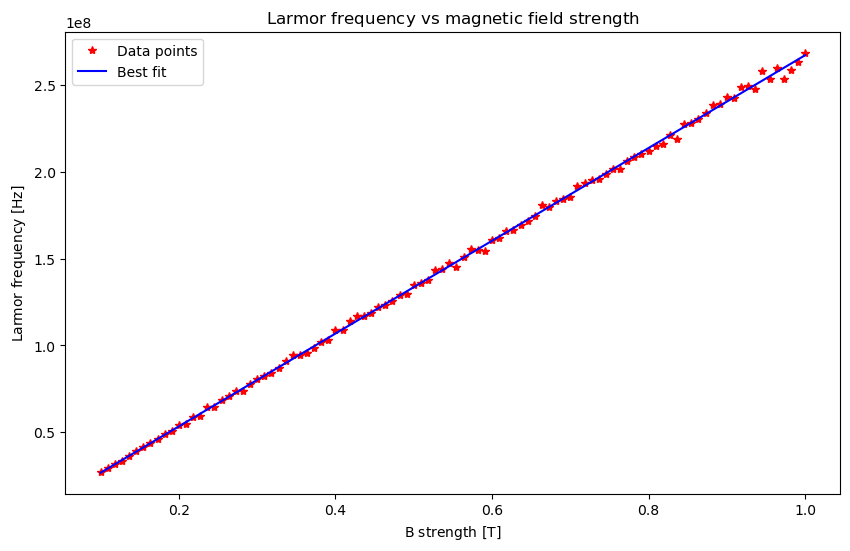

In [12]:
#Plotting
plt.figure(figsize=(10,6))

# Plot
plt.plot(b_stg, freq, color = "red", linestyle = "", marker = "*", label = "Data points")
plt.plot(b_stg, fit_larmor, color = "blue", linestyle = "-", label = "Best fit")

# Title with latex syntax
plt.title(r"$\text{Larmor frequency vs magnetic field strength}$") 

# Axes titles
plt.xlabel(r"$\text{B strength [T]}$")
plt.ylabel(r"$\text{Larmor frequency [Hz]}$")

# Show
plt.legend()
plt.show()
plt.close()

From the table below, it can be inferred that the particle is a hydrogen atom, $H$.
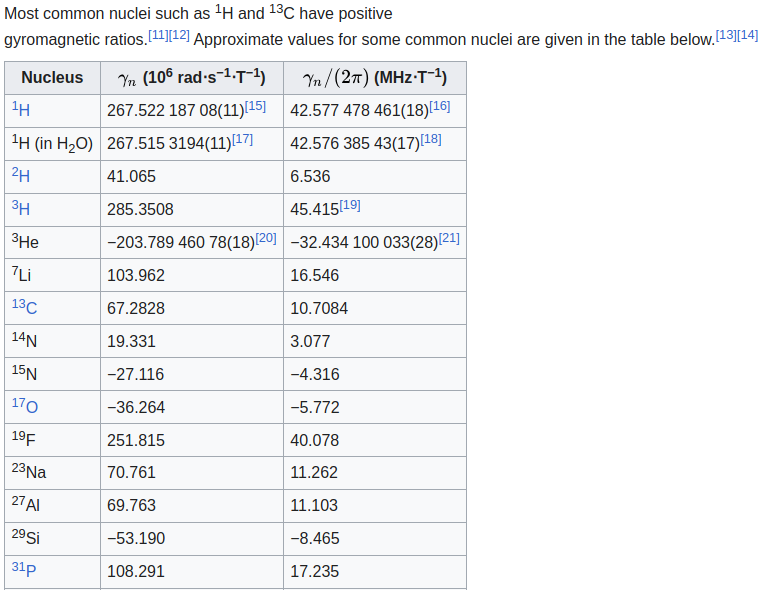

Retrieved from: https://en.wikipedia.org/wiki/Gyromagnetic_ratio

## 6. Image processing: Scanning Electron Microscope of Escherichia coli (5 points)

### a) Create a python function that reads in an image file and returns one its channels as an array.

In [13]:
#Import useful libraries
import matplotlib.cbook as cbook

In [14]:
def read_img(filename, channel):
    """
    This function reads an RGB image an selects one of its channels by converting it to an array.
    Inputs: filename(str), channel(integer: 0,1 or 2.)
    Output: layer(array)
    """
    #Open the image
    image_file = cbook.get_sample_data(filename)

    #Convert to an array by using imread
    image = plt.imread(image_file)

    #Select channel
    layer = image[:, :, channel]

    return layer

### b) Call your function from (a), and:

- Make a 2-panel figure showing the before and after SEM images.
- Make a 2-panel figure showing the before and after pixel histograms of the SEM images.

In [15]:
#Add the paths of the images
bacteria_before = "/home/prostofsound/jnotebooks/computational-physics-1/exams/data/bacteria_before.jpg"
bacteria_after = "/home/prostofsound/jnotebooks/computational-physics-1/exams/data/bacteria_after.jpg"

In [16]:
#Call the image reader
bact_bef_layer = read_img(bacteria_before, 1)
bact_aft_layer = read_img(bacteria_after, 1)

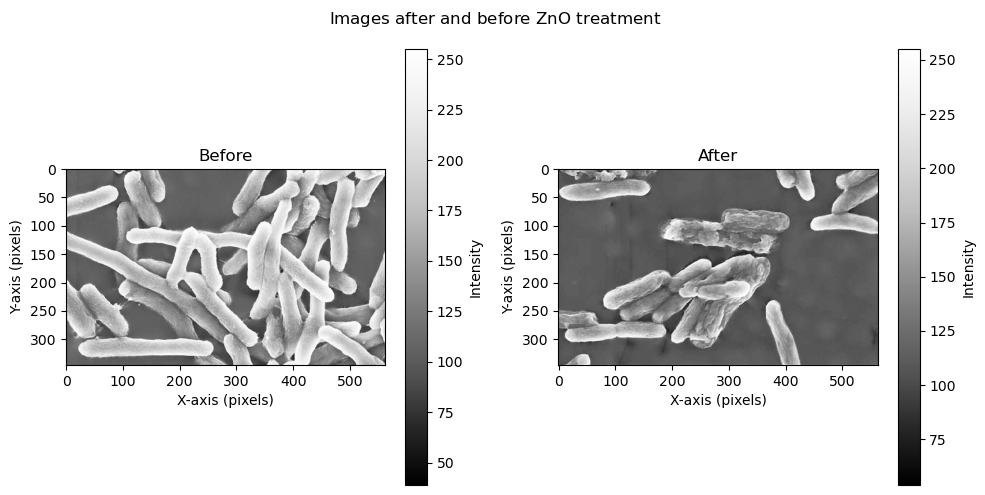

In [17]:
#Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(r"$\text{Images after and before ZnO treatment}$")

# Plot first image
im1 = axes[0].imshow(bact_bef_layer, cmap="Greys_r")
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label("Intensity")
axes[0].set_title("Before")
axes[0].set_xlabel("X-axis (pixels)")  
axes[0].set_ylabel("Y-axis (pixels)")


# Plot second image
im2 = axes[1].imshow(bact_aft_layer, cmap="Greys_r")
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label("Intensity")
axes[1].set_title("After")
axes[1].set_xlabel("X-axis (pixels)")  
axes[1].set_ylabel("Y-axis (pixels)")

# Show the figure
plt.tight_layout()
plt.show()
plt.close()

In [18]:
#Reshape to 1D
bact_bef_1D = np.reshape(bact_bef_layer , (bact_bef_layer .size, 1))
bact_aft_1D = np.reshape(bact_aft_layer , (bact_aft_layer .size, 1))

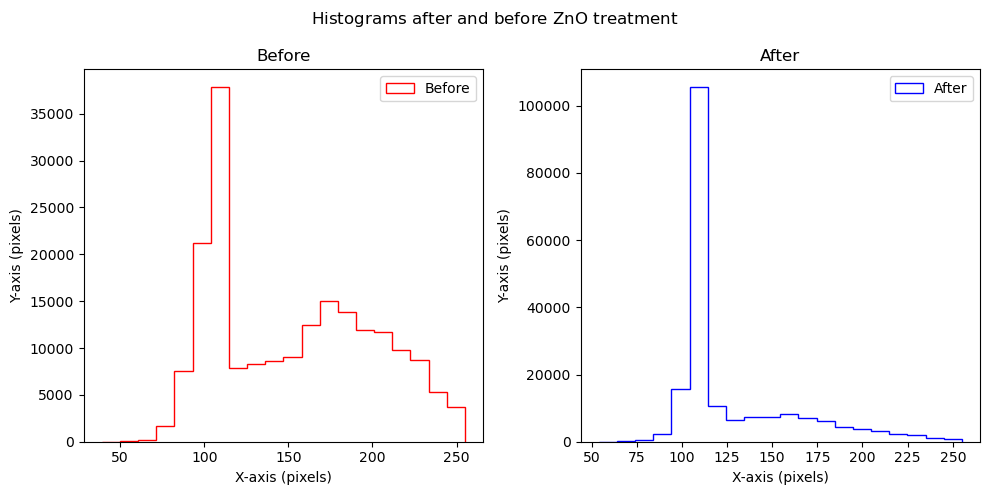

In [19]:
#Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(r"$\text{Histograms after and before ZnO treatment}$")

# Plot first image
axes[0].hist(bact_bef_1D, bins = 20, histtype='step', color='red', label='Before')
axes[0].set_title("Before")
axes[0].set_xlabel("X-axis (pixels)")  
axes[0].set_ylabel("Y-axis (pixels)")
axes[0].legend()


# Plot first image
axes[1].hist(bact_aft_1D, bins = 20, histtype='step', color='blue', label='After')
axes[1].set_title("After")
axes[1].set_xlabel("X-axis (pixels)")  
axes[1].set_ylabel("Y-axis (pixels)")
axes[1].legend()

# Show the figure
plt.tight_layout()
plt.show()
plt.close()

### c) Create a python function that isolates the area covered by the E. coli bacteria from the background. Your function should read in an image channel array and return a cleaned binary image array with zeroes in the background and ones in the E. coli area.


In [20]:
def clean_img(image, tr):
    """
    This functions uses thresholding to isolate the bacteria from the background.
    Inputs: image (array), tr (float, the thresholding intensity value.)
    Output: clean_image (array)
    """
    clean_image = np.where(image > tr, 1., 0. )

    return clean_image

### d) Call your function from (c), and:
- Make a 2-panel figure showing the before and after binary images.
- Make a 2-panel figure showing the before and after pixel histograms of the binary images.

In [21]:
clean_bact_bef = clean_img(bact_bef_layer, 145)
clean_bact_aft = clean_img(bact_aft_layer, 145)

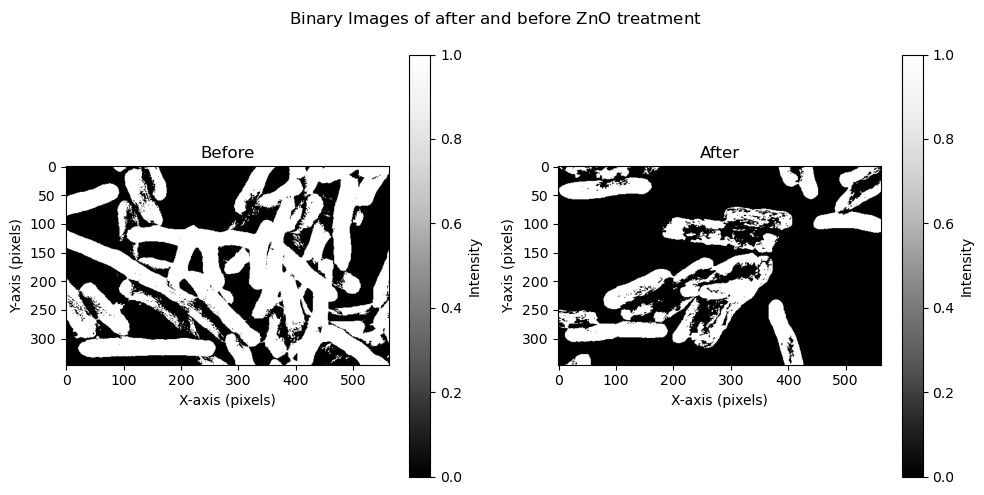

In [22]:
#Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(r"$\text{Binary Images of after and before ZnO treatment}$")

# Plot first image
im1 = axes[0].imshow(clean_bact_bef, cmap="Greys_r")
cbar1 = fig.colorbar(im1, ax=axes[0])
cbar1.set_label("Intensity")
axes[0].set_title("Before")
axes[0].set_xlabel("X-axis (pixels)")  
axes[0].set_ylabel("Y-axis (pixels)")


# Plot second image
im2 = axes[1].imshow(clean_bact_aft, cmap="Greys_r")
cbar2 = fig.colorbar(im2, ax=axes[1])
cbar2.set_label("Intensity")
axes[1].set_title("After")
axes[1].set_xlabel("X-axis (pixels)")  
axes[1].set_ylabel("Y-axis (pixels)")

# Show the figure
plt.tight_layout()
plt.show()
plt.close()

In [23]:
#Reshape to 1D
bact_bef_bin_1D = np.reshape(clean_bact_bef, (clean_bact_bef.size, 1))
bact_aft_bin_1D = np.reshape(clean_bact_aft, (clean_bact_aft.size, 1))

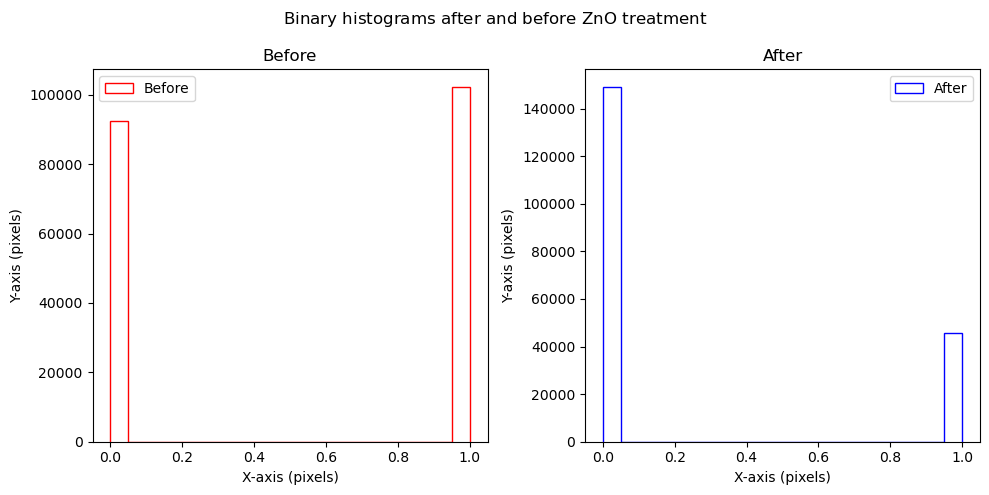

In [24]:
#Plotting
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle(r"$\text{Binary histograms after and before ZnO treatment}$")

# Plot first image
axes[0].hist(bact_bef_bin_1D, bins = 20, histtype='step', color='red', label='Before')
axes[0].set_title("Before")
axes[0].set_xlabel("X-axis (pixels)")  
axes[0].set_ylabel("Y-axis (pixels)")
axes[0].legend()


# Plot first image
axes[1].hist(bact_aft_bin_1D, bins = 20, histtype='step', color='blue', label='After')
axes[1].set_title("After")
axes[1].set_xlabel("X-axis (pixels)")  
axes[1].set_ylabel("Y-axis (pixels)")
axes[1].legend()

# Show the figure
plt.tight_layout()
plt.show()
plt.close()

### e) Using your binary images, calculate the following:

- The total area in pixels and physical units covered by the E. coli bateria before and after treatment.
- The ratio between such areas, how effective is the antibacterial treatment with ZnO nanoparticles?

In [25]:
def area_bact(binary_array):
    """
    This calculates the area of binary images.
    Input: image with 1, 0
    Outpus: total # of pixels, area in um
    """
    
    pixel_area = 0.02**2 # in units of micras^2
    
    number_pixels = np.sum(binary_array) # in pixels
    
    total_area = pixel_area * number_pixels # in micras^2
    
    return number_pixels, total_area

In [26]:
# Call our function:
a_pix_bef, a_phy_bef = area_bact(clean_bact_bef)
a_pix_aft, a_phy_aft = area_bact(clean_bact_aft)

In [27]:
print(f"Before, the area in pixels = {a_pix_bef}\nBefore, the area in microns² = {a_phy_bef}")

Before, the area in pixels = 102224.0
Before, the area in microns² = 40.8896


In [28]:
print(f"After, the area in pixels = {a_pix_aft}\nAfter, the area in microns² = {a_phy_aft}")

After, the area in pixels = 45767.0
After, the area in microns² = 18.306800000000003


In [29]:
# Ratio
print(f"Ratio = {a_pix_aft/a_pix_bef}")

Ratio = 0.44771286586320236


We're left with less than half of the bacteria after the treatment. The process may be more effective after multiple trials.